## Mode Converter

Photonic integrated circuits rely on waveguides that support different optical modes. Efficiently converting light from one mode to another is a fundamental requirement in many optical communication and sensing systems.

This tutorial demonstrates how to design a mode converter using FDTDX, a GPU-accelerated finite-difference time-domain (FDTD) simulation framework with automatic differentiation capabilities. Using inverse design techniques, we optimize a parameterized photonic structure to maximize mode conversion efficiency.

By the end of this tutorial, you will understand:

- How to set up an FDTD simulation in FDTDX.
- How to define a parameterized design region.
- How to add waveguides, sources, and detectors.
- How to formulate an optimization objective.
- How automatic differentiation enables gradient-based optimization.
- How to obtain a final mode converter with conversion efficiencies.

### Imports and Setup

In [66]:
from pathlib import Path
import time
import numpy as np

import fdtdx
import jax
import jax.numpy as jnp
from loguru import logger
import pytreeclass as tc
import optax
import pickle
import matplotlib.pyplot as plt
%matplotlib inline

### Define the functions to save and load the optimizer state

Long-running optimizations can take hours or even days.

To avoid losing progress, helper functions are provided: `save_optimizer_state()` and `load_optimizer_state()`

These functions serialize: Optimization parameters, Optimizer state, Design variables

This allows training to resume from a previous checkpoint.

In [69]:
def save_optimizer_state(opt_state, params, path):
    # Convert JAX arrays to numpy for serialization
    state_np = jax.tree.map(np.array, opt_state)
    params_np = jax.tree.map(np.array, params)
    with open(path, "wb") as f:
        pickle.dump({"opt_state": state_np, "params": params_np}, f)
    print(f"Saved to {path}")


def load_optimizer_state(path):
    with open(path, "rb") as f:
        data = pickle.load(f)
    # Convert numpy arrays back to JAX arrays
    opt_state = jax.tree.map(jnp.array, data["opt_state"])
    params = jax.tree.map(jnp.array, data["params"])
    return opt_state, params

### Basic Simulation setup

Here we define the basic simulation parameters:

- The material type and its permittivity.
- The simulation configuration, which includes parameters such as the simulation duration, grid, numerical precision (dtype), and the Courant stability factor.

In [72]:
optimize: bool = False
generate_video: bool = False
generate_backward_video: bool = False
fixed_beta: float | None = jnp.inf
cw_source : bool = False

epochs = 120
center_wavelength = 1.55e-6
center_wave = fdtdx.WaveCharacter(wavelength=center_wavelength)
height = 220e-9
waveguide_width = 700e-9
material_config = {
    "sio2": fdtdx.Material(permittivity=3.9),
    "si": fdtdx.Material(permittivity=12.25),
}

period = fdtdx.constants.wavelength_to_period(center_wavelength)
exp_logger = fdtdx.Logger(experiment_name="mode_converter")
key = jax.random.PRNGKey(seed=42)

config = fdtdx.SimulationConfig(
    time=600e-15, # if not cw_source else 200e-15,
    grid=fdtdx.UniformGrid(spacing=20e-9),
    #resolution=20e-9,
    dtype=jnp.float32,
    courant_factor=0.99,
)
if optimize or generate_backward_video:
    gradient_config = fdtdx.GradientConfig(
        recorder=fdtdx.Recorder(
            modules=[
                fdtdx.LinearReconstructEveryK(k=8),
                fdtdx.DtypeConversion(dtype=jnp.float8_e4m3b11fnuz),
            ]
        )
    )
    config = config.aset("gradient_config", gradient_config)

Output()

24.06.2026 16:28:12.953 | /Users/vatsallimbachia/fdtdx-repo/src/fdtdx/utils/logger.py:133 - Starting experiment 
mode_converter in /Users/vatsallimbachia/Downloads/outputs/nobackup/2026-06-24/mode_converter/16-28-12.935802

Let's assemble all the objects and constraints in our lists.

In [75]:
object_list, placement_constraints = [], []
all_time_steps = list(range(config.time_steps_total))
period_steps = round(period / config.time_step_duration)
logger.info(f"{config.time_steps_total=}")
logger.info(f"{period_steps=}")
logger.info(f"{config.max_travel_distance=}")

volume = fdtdx.SimulationVolume(
    partial_real_shape=(9.5e-6, 6e-6, 1.7e-6),
    material=material_config["sio2"],
)
object_list.append(volume)

bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(thickness=12, boundary_type="pml")
bound_dict, c_list = fdtdx.boundary_objects_from_config(bound_cfg, volume)
object_list.extend(bound_dict.values())
placement_constraints.extend(c_list)

24.06.2026 16:28:16.336 | /var/folders/9c/sf1_5nb17v51rk1l8xcxshdc0000gn/T/ipykernel_1890/3869389654.py:4 - 
config.time_steps_total=15735

24.06.2026 16:28:16.339 | /var/folders/9c/sf1_5nb17v51rk1l8xcxshdc0000gn/T/ipykernel_1890/3869389654.py:5 - 
period_steps=136

24.06.2026 16:28:16.341 | /var/folders/9c/sf1_5nb17v51rk1l8xcxshdc0000gn/T/ipykernel_1890/3869389654.py:6 - 
config.max_travel_distance=0.00017987547479999998

We will use FDTDX's `place_objects` and `plot_setup`to visualize our basic simulation setup

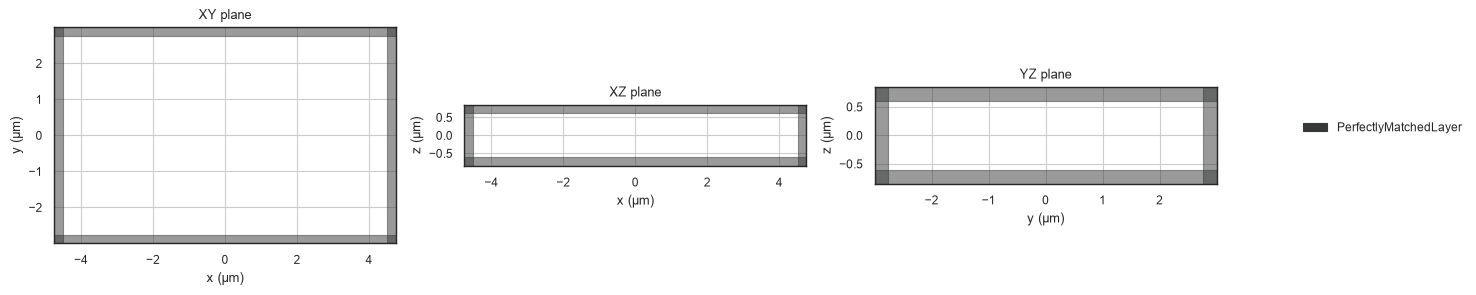

In [78]:
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list = object_list,
    config = config,
    constraints = placement_constraints,
    key = key
)

fig = fdtdx.plot_setup(
    config = config,
    objects = objects
)
plt.show()

### Creating design region

The notebook configures the simulation using a voxel size of: `voxel_size = 20e-9`. This corresponds to a spatial resolution of 20 nm.

A fine resolution is essential for accurately capturing electromagnetic behavior inside nanophotonic structures.

The central component of the optimization problem is the parameterized design region : `device_x = 7e-6` , `device_y = 5e-6`

This region contains the material distribution that will be optimized.

Instead of defining a fixed geometry, the design region is discretized into thousands of pixels.Each pixel is assigned a design variable controlling the local material distribution.

During optimization, these variables are updated continuously. The resulting structure gradually evolves from an initial uniform distribution into a highly functional photonic component.

To improve manufacturability, FDTDX employs Subpixel Smoothed Projection (SSP).Compared to conventional Heaviside projection methods, SSP produces smoother gradients and more accurate subpixel representations of device boundaries, improving both convergence and final device quality.

In [81]:
voxel_size = 20e-9
device_x, device_y = 7e-6, 5e-6
device_x_grid, device_y_grid = round(device_x / voxel_size), round(device_y / voxel_size)
side_x, side_y = jnp.zeros(shape=(device_x_grid,)), jnp.zeros(shape=(device_y_grid,))
waveguide_grid_size = waveguide_width / voxel_size
start_idx = round((device_y_grid - waveguide_grid_size) / 2)
end_idx = round((device_y_grid + waveguide_grid_size) / 2)
side_y = side_y.at[start_idx:end_idx].set(1.0)

device = fdtdx.Device(
    name="Device",
    partial_real_shape=(device_x, device_y, height),
    materials=material_config,
    param_transforms=[
        fdtdx.GaussianSmoothing2D(
            std_discrete=3,
            padding_low_axis1=side_x,
            padding_high_axis1=side_x,
            padding_low_axis0=side_y,
            padding_high_axis0=side_y,
        ),
        fdtdx.SubpixelSmoothedProjection(),
    ],
    partial_voxel_real_shape=(voxel_size, voxel_size, height),
)

object_list.append(device)
placement_constraints.append(device.place_at_center(volume))

We will again use FDTDX's `place_objects` and `plot_setup`to visualize our setup after adding `Device`

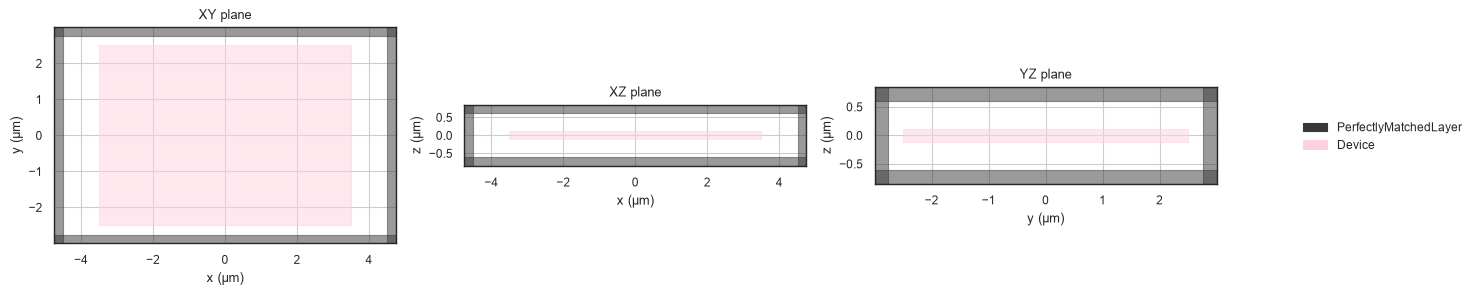

In [84]:
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list = object_list,
    config = config,
    constraints = placement_constraints,
    key = key
)

fig = fdtdx.plot_setup(
    config = config,
    objects = objects
)
plt.show()

### Waveguides

The input waveguide injects the optical signal into the design region using `UniformMaterialObject`

The output waveguide receives the converted mode.

These waveguides remain unchanged throughout optimization and provide a stable interface between the optimized device and the surrounding photonic circuit.

In [87]:
waveguide_in = fdtdx.UniformMaterialObject(
    name="WG_in",
    partial_real_shape=(None, waveguide_width, height),
    material=material_config["si"],
    color=fdtdx.colors.XKCD_LIGHT_BLUE,
)
placement_constraints.extend([
    waveguide_in.place_at_center(device, axes=(1, 2)),
    waveguide_in.extend_to(device, axis=0, direction="+"),
    waveguide_in.extend_to(None, axis=0, direction="-"),
])
object_list.append(waveguide_in)

waveguide_out = fdtdx.UniformMaterialObject(
    name="WG_out",
    partial_real_shape=(None, waveguide_width, height),
    material=material_config["si"],
    color=fdtdx.colors.XKCD_LIGHT_BLUE,
)
placement_constraints.extend(
    [
        waveguide_out.place_at_center(device, axes=(1, 2)),
        waveguide_out.extend_to(device, axis=0, direction="-"),
        waveguide_out.extend_to(None, axis=0, direction="+"),
    ]
)
object_list.append(waveguide_out)

We will again use FDTDX's `place_objects` and `plot_setup`to visualize our setup after adding waveguides

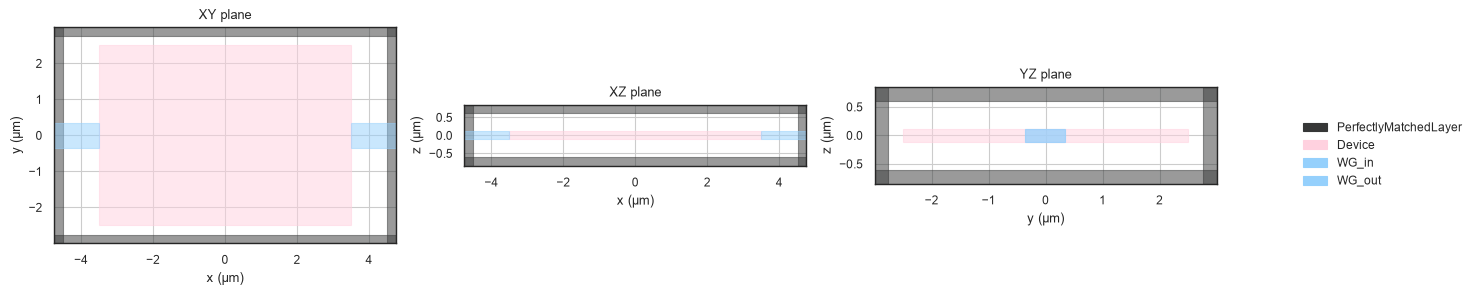

In [90]:
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list = object_list,
    config = config,
    constraints = placement_constraints,
    key = key
)

fig = fdtdx.plot_setup(
    config = config,
    objects = objects
)
plt.show()

### Defining the Mode Source

The excitation is generated using a mode source.

The source launches a specific waveguide eigenmode into the structure.

Depending on the experiment, either:

- Continuous-wave excitation
- Broadband pulse excitation

can be used. A pulse contains many frequencies simultaneously, which is why it can be used to measure the broadband response of the design. It is generally always recommended to use a pulse because it also makes the calculation more accurate for a single frequency. With CW excitation, it takes a very long time for the entire simulation to reach steady state, which is why 
it is less accurate.

The mode source ensures that only the desired input mode is injected into the device.

In [93]:
monitor_pad_y = 300e-9
monitor_pad_z = 200e-9
if cw_source:
    temporal_profile = fdtdx.SingleFrequencyProfile()
    switch = fdtdx.OnOffSwitch(
        fixed_on_time_steps=all_time_steps[-2*period_steps:]
    )
else:
    temporal_profile= fdtdx.GaussianPulseProfile(
        center_wave=center_wave,
        spectral_width=fdtdx.WaveCharacter(wavelength=center_wavelength*10),
    )
    switch = fdtdx.OnOffSwitch()
        
source = fdtdx.ModePlaneSource(
    name="Mode source",
    partial_grid_shape=(1, None, None),
    # partial_real_shape=(None, waveguide_width + 2 * monitor_pad_y, height + 2 * monitor_pad_z),
    wave_character=center_wave,
    temporal_profile=temporal_profile,
    direction="+",
    mode_index=0,
    filter_pol="te",
    color=fdtdx.colors.XKCD_BLUE,
)

placement_constraints.extend([
    source.place_relative_to(
        waveguide_in,
        axes=0,
        other_positions=-1,
        own_positions=1,
        margins=100e-9,
        grid_margins=bound_cfg.thickness_grid_minx + 5,
    ),
    source.place_at_center(waveguide_in, axes=(1, 2)),
])
object_list.append(source)

Here we will visualize the object after adding `ModePlaneSource`

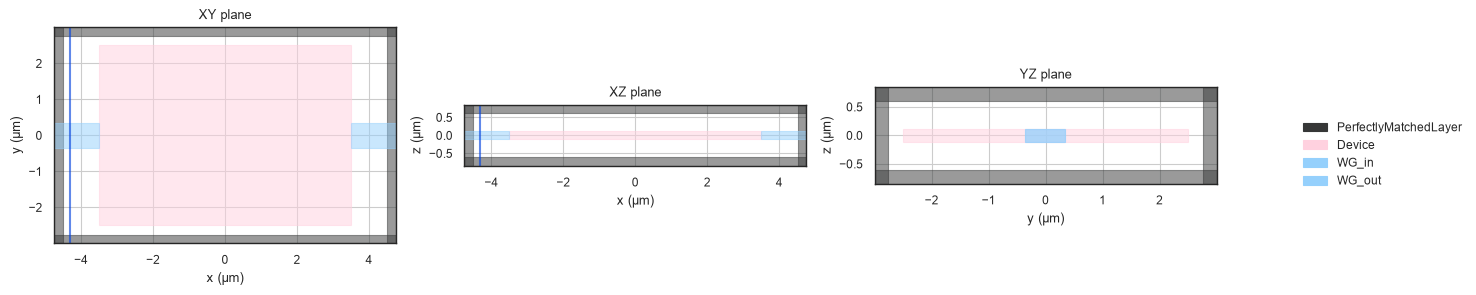

In [96]:
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list = object_list,
    config = config,
    constraints = placement_constraints,
    key = key
)

fig = fdtdx.plot_setup(
    config = config,
    objects = objects
)
plt.show()

### Adding Detectors

Detectors measure the electromagnetic fields during simulation.

The notebook uses several detector types:

- Input Detector: measures incoming power.
- Output Detector: measures transmitted power in the target mode.
- Field Detector: records field distributions for visualization.

These detectors provide the data required to evaluate device performance. You need both input and output detectors to measure the transmission from one mode to another (in fdtdx, the source is not normalized—work in progress), which is why you need the input detector.

In [99]:
broadband_wls = np.linspace(1.5e-6, 1.6e-6, 101)
broadband_characters = [fdtdx.WaveCharacter(wavelength=wl) for wl in broadband_wls]
mode_input_detector = fdtdx.ModeOverlapDetector(
    name="input_detector",
    direction="+",
    mode_index=0,
    switch=switch,
    filter_pol="te",
    wave_characters=(center_wave,),
    # wave_characters=(broadband_characters[idx],),
    color=fdtdx.colors.XKCD_BRIGHT_GREEN,
    scaling_mode="pulse" if not cw_source else "continuous",
)
placement_constraints.extend([
    mode_input_detector.same_size(source),
    mode_input_detector.place_at_center(waveguide_in, axes=(1, 2)),
    mode_input_detector.same_position(source, axes=0, grid_margins=5),
])
object_list.append(mode_input_detector)

mode_output_detector = fdtdx.ModeOverlapDetector(
    name="output_detector",
    direction="+",
    mode_index=1,
    switch=switch,
    filter_pol="te",
    wave_characters=(center_wave,),
    # wave_characters=(broadband_characters[idx],),
    color=fdtdx.colors.XKCD_RED,
    scaling_mode="pulse" if not cw_source else "continuous",
)
placement_constraints.extend([
    mode_output_detector.same_size(source),
    mode_output_detector.place_at_center(waveguide_in, axes=(1, 2)),
    mode_output_detector.place_relative_to(
        volume, 
        own_positions=0,
        other_positions=1,
        axes=0,
        margins=-100e-9,
        grid_margins=-bound_cfg.thickness_grid_minx - 5
    ),
])
object_list.append(mode_output_detector)

Visualize the detectors inserted in the object

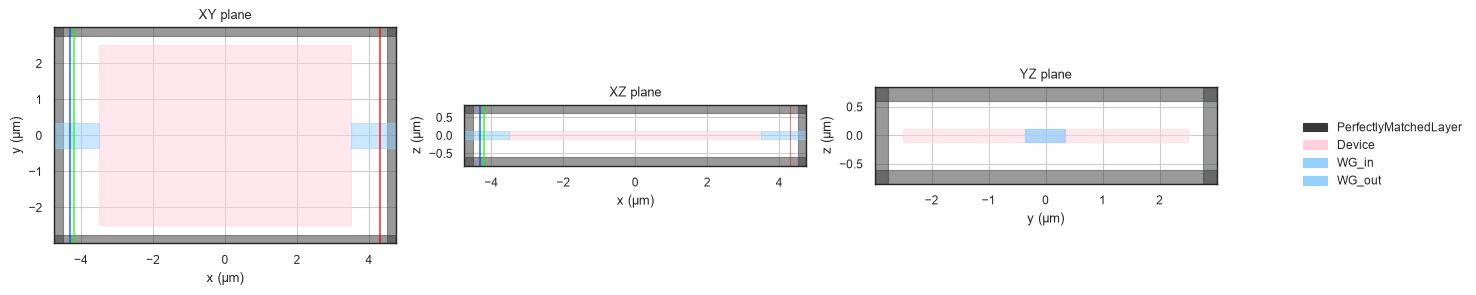

In [102]:
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list = object_list,
    config = config,
    constraints = placement_constraints,
    key = key
)

fig = fdtdx.plot_setup(
    config = config,
    objects = objects
)
plt.show()

### Visualization Detectors

In [ ]:
field_detector = fdtdx.PhasorDetector(
    name="field",
    partial_grid_shape=(None, None, 1),
    wave_characters=[fdtdx.WaveCharacter(wavelength=1.55e-6)],
    switch=switch,
    scaling_mode="pulse" if not cw_source else "continuous",
)
object_list.append(field_detector)
placement_constraints.extend([
    field_detector.place_at_center(volume, axes=2)
])

plot_exclude = []
if generate_video:
    video_energy_detector = fdtdx.EnergyDetector(
        name="Video",
        as_slices=True,
        switch=fdtdx.OnOffSwitch(interval=10),
        exact_interpolation=True,
        num_video_workers=8,
    )
    object_list.append(video_energy_detector)
    placement_constraints.extend(video_energy_detector.same_position_and_size(volume))
    plot_exclude.append(video_energy_detector)

if generate_backward_video:
    back_video_energy_detector = fdtdx.EnergyDetector(
        name="Backwards Video",
        as_slices=True,
        switch=fdtdx.OnOffSwitch(interval=10),
        exact_interpolation=True,
        num_video_workers=8,
        inverse=True,
    )
    object_list.append(back_video_energy_detector)
    placement_constraints.extend(back_video_energy_detector.same_position_and_size(volume))
    plot_exclude.append(back_video_energy_detector)

key, subkey = jax.random.split(key)
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list=object_list,
    config=config,
    constraints=placement_constraints,
    key=subkey,
)

logger.info(tc.tree_summary(arrays, depth=2))
print(tc.tree_diagram(config, depth=4))

exp_logger.savefig(
    exp_logger.cwd,
    "setup.png",
    fdtdx.plot_setup(
        config=config,
        objects=objects,
        exclude_object_list=plot_exclude,
    ),
)

### Optimization Setup

The notebook uses `Optax` for optimization.

A warmup cosine learning-rate schedule is employed: `optax.warmup_cosine_decay_schedule(...)`

This strategy:

- Starts with conservative updates
- Accelerates optimization
- Stabilizes convergence near the optimum

The optimizer updates thousands of design variables simultaneously using gradient information. The cosine learning rate schedule is used only to increase the learning rate linearly and then keep it at a constant high level. You can experiment a lot with this LR schedule, and the parameters you choose often make a difference. Above all, it’s important that the beta schedule is increased incrementally to provide the optimization with a stable target (continuous changes—such as a linear increase in beta—can make the process unstable). 

It is also important to reset the optimizer state (momentum) after every change to beta and, in effect, start "a new optimization."

In [53]:
schedule: optax.Schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.01,
    peak_value=0.05,
    end_value=0.05,
    warmup_steps=5,
    decay_steps=epochs,
)
optimizer = optax.inject_hyperparams(optax.nadam)(learning_rate=schedule)
optimizer = optax.MultiSteps(optimizer, every_k_schedule=1)

def beta_schedule(query: int) -> jax.Array:
    if fixed_beta is not None:
        return jnp.asarray(fixed_beta)
    # return jnp.asarray(5.0)
    switching_points = [20, 30, 40, 50, 60, 70, 80, 90]
    return_values = [1.0, 2.0, 3.0, 4.0, 5.0, 7.5, 10.0, 20.0, jnp.inf]
    switching_points = jnp.asarray(switching_points)
        
    branches = tuple(lambda _, v=jnp.asarray(val): v for val in return_values)
    idx = jnp.searchsorted(switching_points, query)
    beta = jax.lax.switch(idx, branches, None)
    return beta

changed_voxels = exp_logger.log_params(
    iter_idx=0,
    params=params,
    objects=objects,
    export_stl=True,
    export_figure=True,
    beta=beta_schedule(0)
)

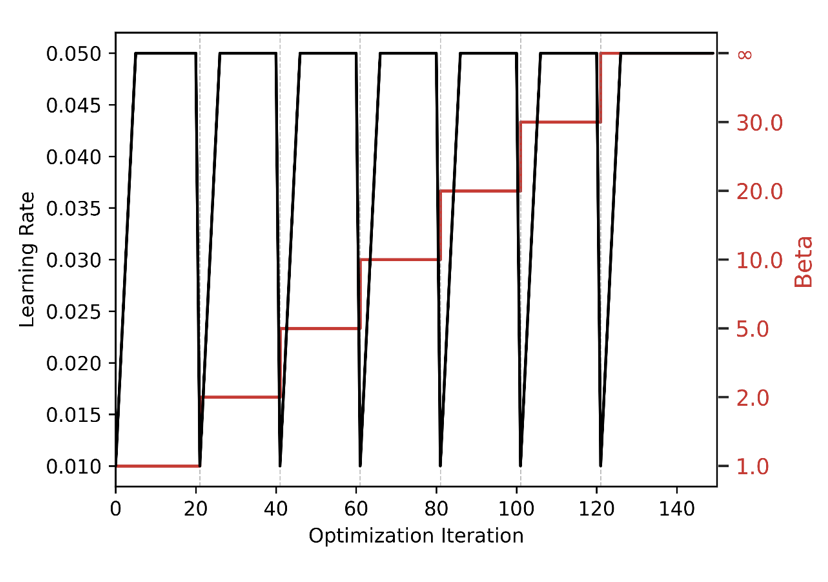

### Loss function

In the Loss function, the simulation is simply set up (`apply_params`, which also runs SSP and calculates the modes), then the FDTD simulation is performed (`run_fdtd`), and finally the transmission is calculated. It is important here to use the objects after `apply_params` because they contain the information about the calculated modes.

In [109]:
def loss_fn(params, arrays, key, idx: int):
    # Apply parameters to objects and arrays
    arrays, new_objects, info = fdtdx.apply_params(arrays, objects, params, key, beta=beta_schedule(idx))

    # Run FDTD simulation
    final_state = fdtdx.run_fdtd(
        arrays=arrays,
        objects=new_objects,
        config=config,
        key=key,
        show_progress=False,
    )

    # Extract updated arrays from simulation state
    _, arrays = final_state

    if generate_backward_video:
        _, arrays = fdtdx.full_backward(
            state=final_state,
            objects=new_objects,
            config=config,
            key=key,
            record_detectors=True,
            reset_fields=True,
        )

    input_detector_with_mode = new_objects[mode_input_detector.name]
    output_detector_with_mode = new_objects[mode_output_detector.name]
    assert isinstance(input_detector_with_mode, fdtdx.ModeOverlapDetector)
    assert isinstance(output_detector_with_mode, fdtdx.ModeOverlapDetector)

    raw_input_overlap = input_detector_with_mode.compute_overlap(arrays.detector_states[input_detector_with_mode.name])
    raw_output_overlap = output_detector_with_mode.compute_overlap(arrays.detector_states[output_detector_with_mode.name])

    info = {
        "input_power": jax.lax.stop_gradient(jnp.square(jnp.abs(raw_input_overlap))),
        "output_power": jnp.square(jnp.abs(raw_output_overlap)),
    }
    transmission = info["output_power"] / info["input_power"]
    info["transmission"] = transmission

    # info = {}
    # transmission = 0.5

    return -transmission, (arrays, info)

### Gradient Optimization Loop

In the optimization loop, the loss/gradient is calculated, then the parameters are updated (based on the optimizer schedule described above), and finally, a few visualizations and pieces of information are logged.

In [ ]:
compile_start_time = time.time()
print("Started Compilation...")
jit_task_id = exp_logger.progress.add_task("JIT", total=None)
idx_dummy_arr = jnp.asarray(0, dtype=jnp.float32)
if not optimize:
    # JIT loss function for evaluation mode
    jitted_loss = jax.jit(loss_fn, donate_argnames=["arrays"]).lower(params, arrays, key, idx_dummy_arr).compile()
else:
    # JIT loss and gradient function for optimization mode
    jitted_loss = (
        jax.jit(jax.value_and_grad(loss_fn, has_aux=True), donate_argnames=["arrays"])
        .lower(params, arrays, key, idx_dummy_arr)
        .compile()
    )
compile_delta_time = time.time() - compile_start_time
exp_logger.progress.update(jit_task_id, total=1, completed=1, refresh=True)
print(f"Finished Compilation in {compile_delta_time} seconds")

opt_state: optax.OptState = optimizer.init(params)
optim_task_id = exp_logger.progress.add_task("Optimization", total=1 if not optimize else epochs)
last_beta = -1
for iter_idx in range(0, 1 if not optimize else epochs):
    # Start timer for this epoch
    run_start_time = time.time()
    key, subkey = jax.random.split(key)
    idx_arr = jnp.asarray(iter_idx, dtype=jnp.float32)
    cur_beta = beta_schedule(iter_idx)
    # if cur_beta != last_beta:
    #     # reinit opt for new beta value
    #     opt_state: optax.OptState = optimizer.init(params)
    #     last_beta = cur_beta

    if not optimize:
        # Run evaluation step
        loss, (arrays, info) = jitted_loss(params, arrays, subkey, idx_arr)
    else:
        # Run optimization step and compute gradients
        (loss, (arrays, info)), grads = jitted_loss(params, arrays, subkey, idx_arr)

        # Update optimizer state and parameters
        updates, opt_state = optimizer.update(grads, opt_state, params)
        info["lr"] = opt_state.inner_opt_state.hyperparams["learning_rate"]
        info["beta"] = float(cur_beta)
        params = optax.apply_updates(params, updates)
        # Clip parameters to [0, 1] range
        params = jax.tree_util.tree_map(lambda p: jnp.clip(p, 0, 1), params)
        # Log gradient and update norms
        info["grad_norm"] = optax.global_norm(grads)
        info["update_norm"] = optax.global_norm(updates)

    # Compute runtime for this epoch
    runtime_delta = time.time() - run_start_time
    info["runtime"] = runtime_delta
    # Compute attenuation metric for logging
    info["attenuation"] = 10 * jnp.log10(-loss)

    # Log compile and runtime info during evaluation
    if not optimize:
        logger.info(f"{compile_delta_time=}")
        logger.info(f"{runtime_delta=}")

    # Log parameters and export figures/STL files for this epoch
    changed_voxels = exp_logger.log_params(
        iter_idx=iter_idx,
        params=params,
        objects=objects,
        export_stl=True,
        export_figure=True,
        beta=beta_schedule(iter_idx)
    )
    info["changed_voxels"] = changed_voxels

    # Write all info to experiment log
    exp_logger.write(info)
    exp_logger.progress.update(optim_task_id, advance=1)

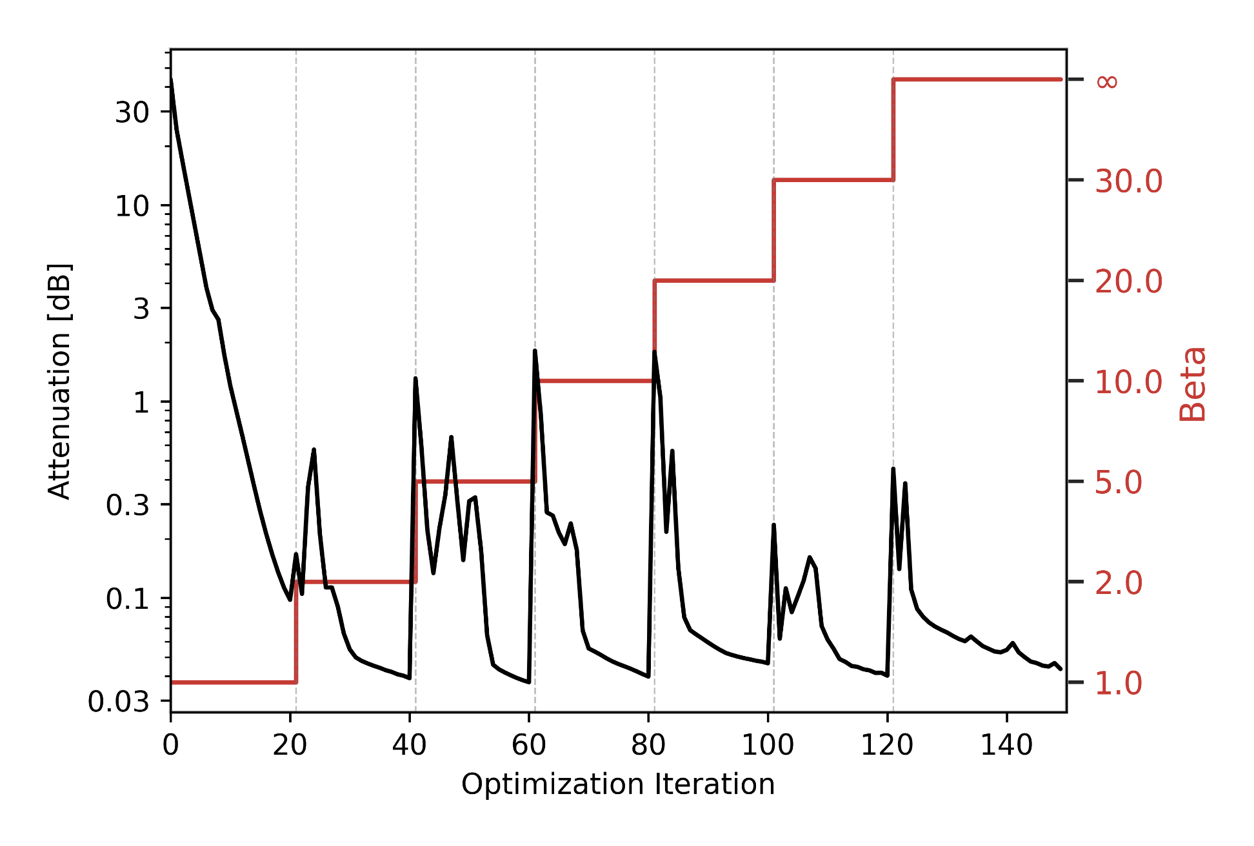


### Design during Optimization

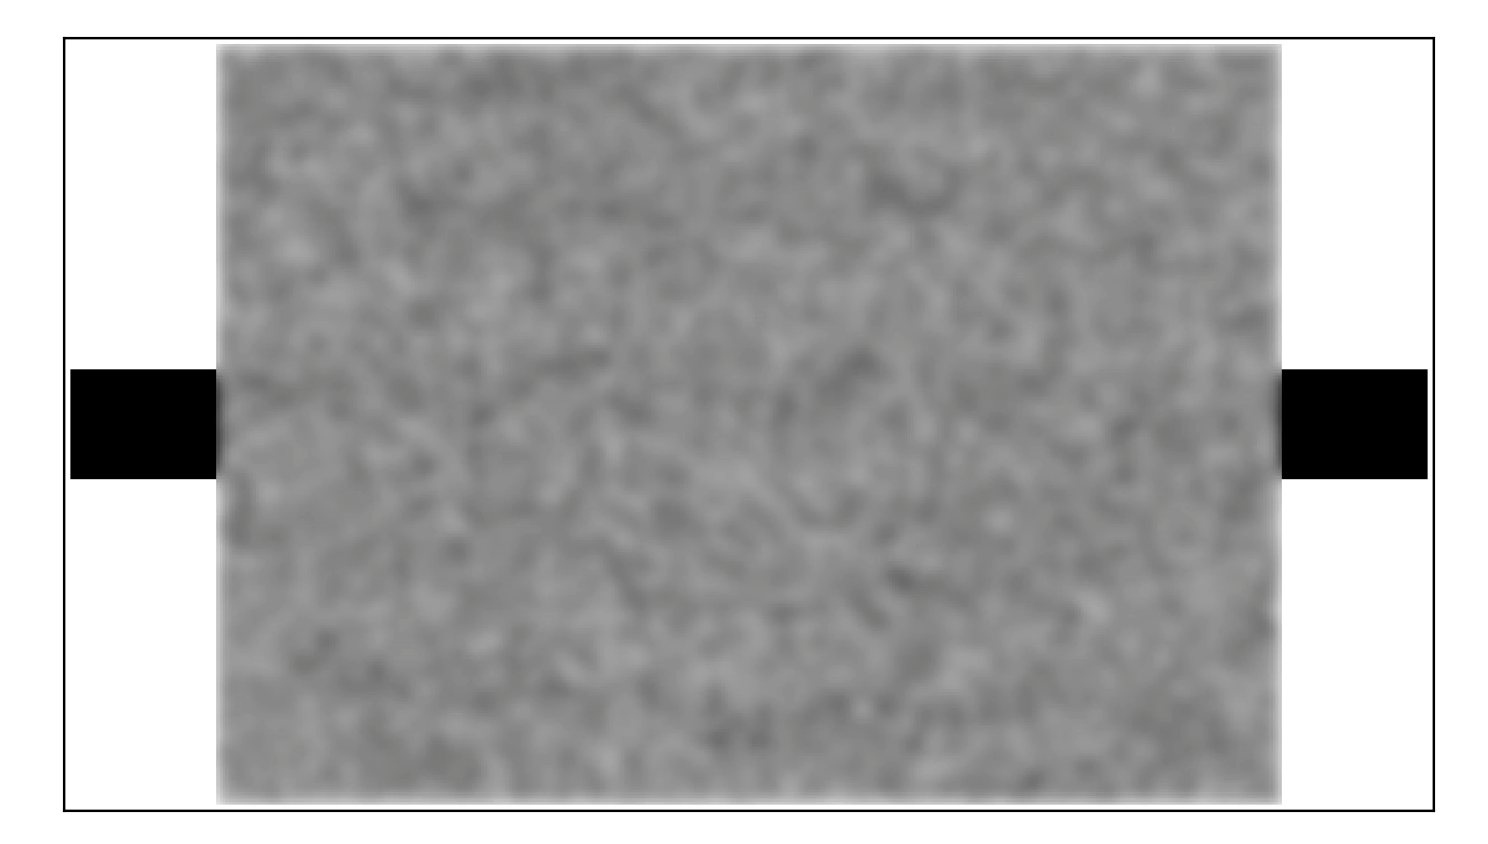

### Final Design

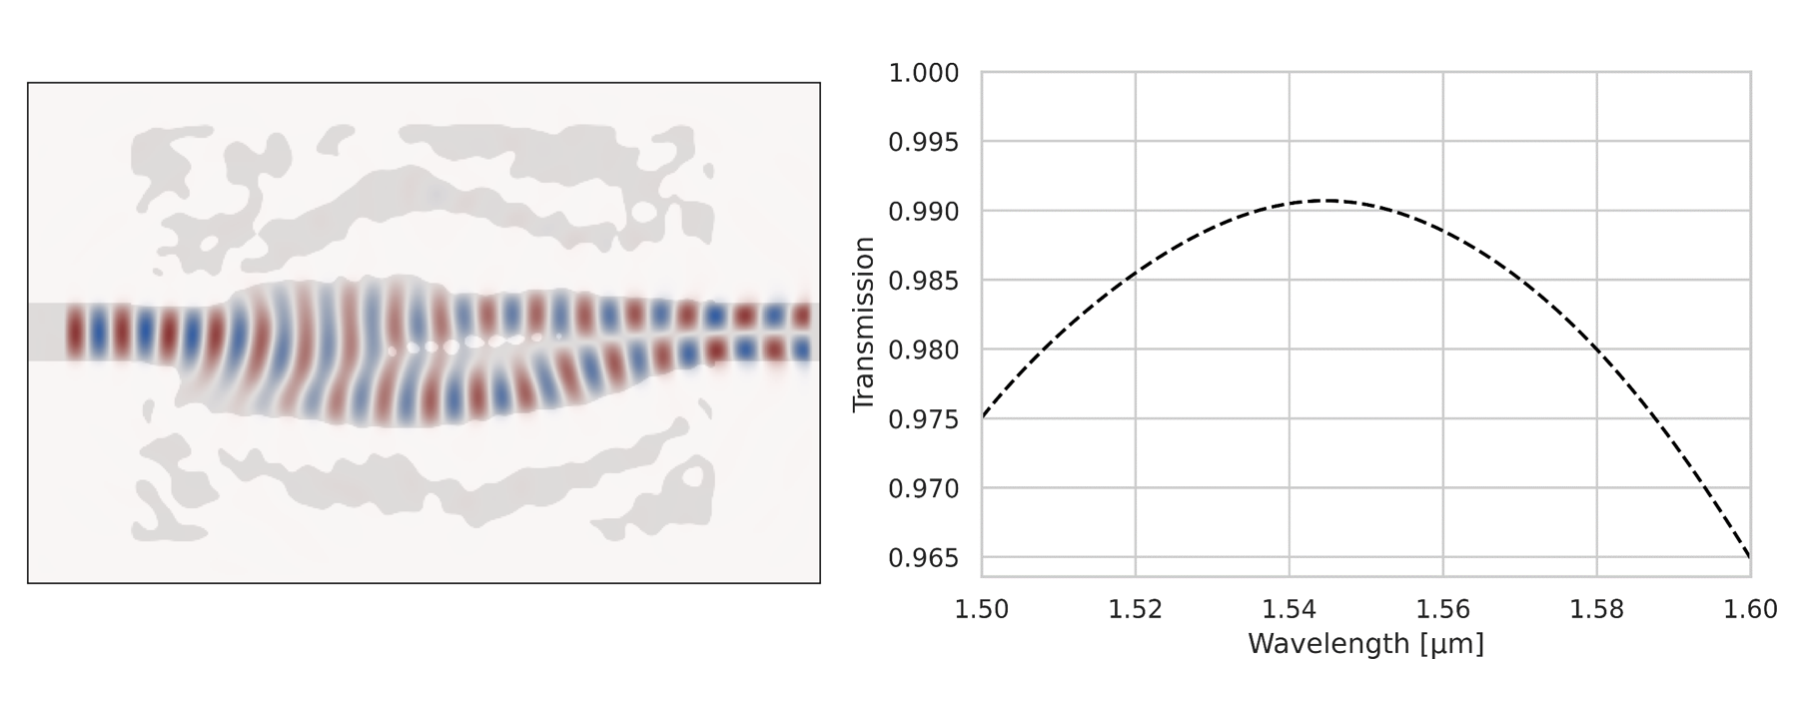